In [2]:
!pip install opencv-python scikit-image pillow joblib

# Image Processing

## Load all libraries

In [50]:
import cv2
import numpy as np
import pandas as pd
import os
import joblib
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from skimage.feature import hog, local_binary_pattern
import matplotlib.pyplot as plt
import random
from scipy.ndimage import label as scipy_label
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

In [13]:
teams = { 0:'No team', 1:'CSK', 2:'DC', 3:'GT', 4:'KKR', 5:'LSG', 6:'MI', 7:'PBKS', 8:'RCB', 9:'RR', 10:'SRH' }

#Image resizing to 800x600 and filtering out images smaller than that
def preprocess_image(image_path, target_size=(800, 600)):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error loading image: {image_path}")
        return None
    h, w = image.shape[:2]
    if h < 600 or w < 800:
        print(f"Image too small: {image_path} - Skipping")
        return None
    image = cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)
    return image

Image_path = 'Latest images load/'
output_dir = 'Processed images/'
os.makedirs(output_dir, exist_ok=True)
for fname in os.listdir(Image_path):
    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        img = preprocess_image(os.path.join(Image_path, fname))
        if img is not None:
            cv2.imwrite(os.path.join(output_dir, fname), img)
            print(f"Processed image: {fname} - Shape: {img.shape}")

Processed image: 1777829868268_Gujarat-Titans.jpg - Shape: (600, 800, 3)
Processed image: 20gujarat-titans1.jpg - Shape: (600, 800, 3)
Processed image: 417308.jpg - Shape: (600, 800, 3)
Error loading image: Latest images load/CRICKET-IPL-RCB-KKR--9_1778700733597.jpg
Error loading image: Latest images load/GT-1.jpg
Processed image: gt-10.jpg - Shape: (600, 800, 3)
Processed image: GT-12.jpg - Shape: (600, 800, 3)
Image too small: Latest images load/GT-13.jpg - Skipping
Processed image: gt-14.jpg - Shape: (600, 800, 3)
Processed image: GT-15.jpg - Shape: (600, 800, 3)
Processed image: GT-2.jpg - Shape: (600, 800, 3)
Error loading image: Latest images load/GT-3.jpg
Image too small: Latest images load/gt-4.jpg - Skipping
Processed image: GT-5.jpg - Shape: (600, 800, 3)
Image too small: Latest images load/GT-6.jpg - Skipping
Processed image: GT-7.jpg - Shape: (600, 800, 3)
Processed image: gt-8.jpg - Shape: (600, 800, 3)
Processed image: gt-9.jpg - Shape: (600, 800, 3)
Error loading image: 

Attempting to load image from path: Latest images load/PBKSvsMI_image_67.jpg


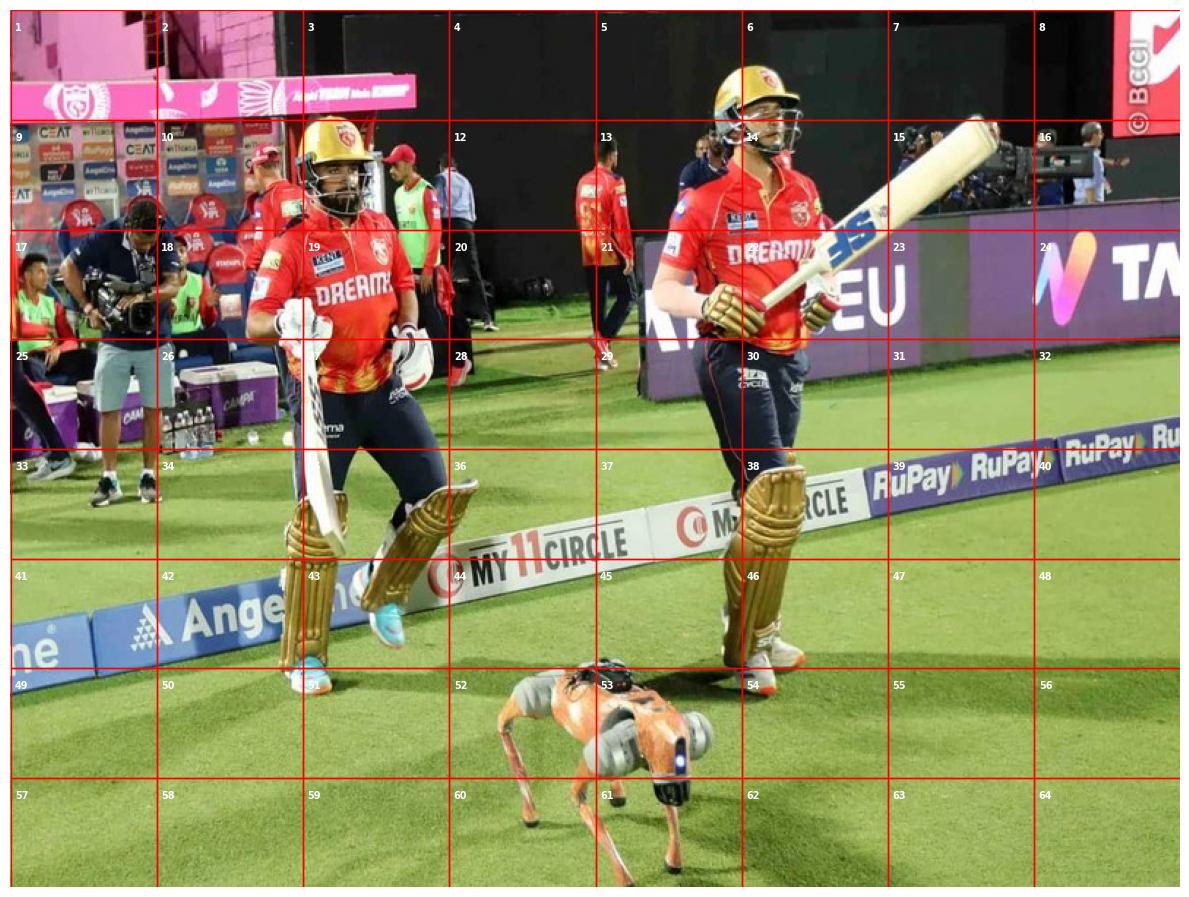

In [ ]:
# Function to extract 64 cells from the image by sliting it into an 8x8 grid
def get_all_cells(image):
    cells = {}
    for row in range(8):
        for col in range(8):
            n = row * 8 + col + 1
            y1 = row * 75
            x1 = col * 100
            cells["c%02d" % n] = image[y1:y1+75, x1:x1+100]
    return cells

def show_grid(path):
    raw_image = cv2.imread(path)
    print(f"Attempting to load image from path: {path}")
    if raw_image is None:
        print(f"Error: Could not load image at path: {path}")
        print(f"Current Working Directory is: {os.getcwd()}")
        return
    image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(image)
    for row in range(8):
        for col in range(8):
            n = row * 8 + col + 1
            ax.text(col * 100 + 3, row * 75 + 14, str(n), color='white', fontsize=7, fontweight='bold')
            ax.add_patch(plt.Rectangle((col * 100, row * 75), 100, 75, fill = False, edgecolor='red', linewidth=1))
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
show_grid('Latest images load/PBKSvsMI_image_67.jpg')

# Label Dataset Cleaning

In [15]:
df = pd.read_csv('labelled_dataset.csv')
df.rename(columns={'image': 'Image File Name'}, inplace=True)
df.insert(1, "Train Or Test", "Train")
df.drop(columns=['labelled_by', 'num_players'], inplace=True)
cell_cols = ['c%02d' % n for n in range(1, 65)]
#print("DataFrame columns: ", list(df.columns), "\nExpected columns: ", ['Image File Name', 'Train Or Test'] + cell_cols)
expected_cols = ['Image File Name', 'Train Or Test'] + cell_cols
assert list(df.columns) == expected_cols, "DataFrame columns do not match expected format"

#df.to_csv('annotated_dataset.csv', index=False)
print("Saved fixed dataset to annotated_dataset.csv \n Shape: ", df.shape)

Saved fixed dataset to annotated_dataset.csv 
 Shape:  (3958, 66)


# EDA - Visualization

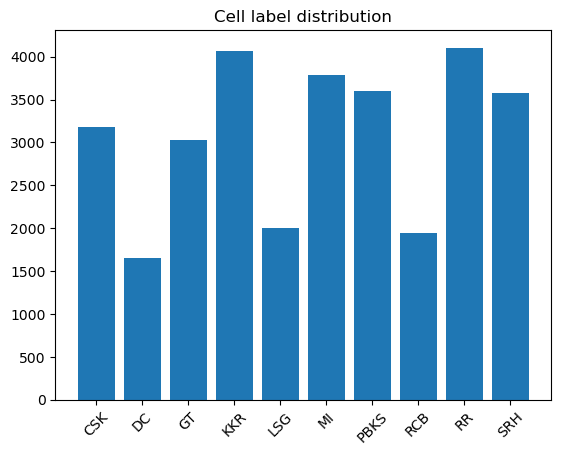

In [16]:
from collections import Counter
import matplotlib.pyplot as plt
flat = df[cell_cols].values.flatten()
dist = Counter(flat)
TEAM_NAMES = [teams[i] for i in range(1,11)]
plt.bar(TEAM_NAMES, [dist.get(i,0) for i in range(1,11)])
plt.title("Cell label distribution")
plt.xticks(rotation=45); plt.show()

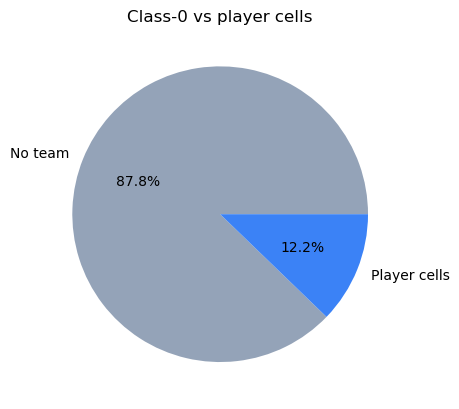

In [20]:
flat = df[cell_cols].values.flatten()
player = (flat != 0).sum()
none_c  = (flat == 0).sum()
plt.pie([none_c, player],
        labels=["No team", "Player cells"],
        autopct="%1.1f%%", colors=["#94a3b8","#3b82f6"])
plt.title("Class-0 vs player cells"); plt.show()

# Feature Extraction

In [17]:
def extract_features(cell_bgr):
    features = []
    hsv = cv2.cvtColor(cell_bgr, cv2.COLOR_BGR2HSV)
    for ch, bins, rng in [(0, 30, (0,180)), (1, 16, (0, 256)), (2, 16, (0, 256))]:
        hist = cv2.calcHist([hsv], [ch], None, [bins], list(rng)).flatten()
        features.extend(hist / hist.sum() + 1e-7)
    
    gray = cv2.cvtColor(cell_bgr, cv2.COLOR_BGR2GRAY)
    hog_features = hog(gray, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(2, 2), feature_vector=True)
    features.extend(hog_features)
    
    lbp = local_binary_pattern(gray, P=9, R=2, method='uniform')
    lbp_hist, _ = np.histogram(lbp, bins=18, range=(0, 18), density=True)
    features.extend(lbp_hist)
    
    return np.array(features, dtype=np.float32)

# Label and Annotation

In [18]:
def build_dataset(image_path, annotations_csv_path):
    df = pd.read_csv(annotations_csv_path) 
    X, y = [], []
    total = len(df)
    df.head()  # Display the first few rows to verify the structure
    for idx, row in df.iterrows():
        path = os.path.join(image_path, row['Image File Name'])
        #print(path)
        image = preprocess_image(path)
        #print(image)
        if image is None:
            #print(f"Error loading image: {path} - Skipping")
            continue
        for cid, cell in get_all_cells(image).items():
            X.append(extract_features(cell))
            y.append(row[cid])
        print(f"Processed {idx+1}/{total} images", end='\r')
    print("\nFinished building dataset.")
    return np.array(X), np.array(y)

X, y = build_dataset('Processed images/', 'annotated_dataset.csv')

Error loading image: Processed images/CRICKET-IPL-RCB-KKR--9_1778700733597.jpg
Error loading image: Processed images/GT-1.jpg
Error loading image: Processed images/GT-13.jpg
Error loading image: Processed images/GT-3.jpg
Error loading image: Processed images/GT-6.jpg
Error loading image: Processed images/GT-KKR-6.jpg
Error loading image: Processed images/GTvsCSK.jpg
Error loading image: Processed images/GTvsDC.jpg
Error loading image: Processed images/Gujarat-Titans21.jpg
Error loading image: Processed images/Gujarat-Titans4.jpg
Error loading image: Processed images/KKR10.jpg
Error loading image: Processed images/KKR12.jpg
Error loading image: Processed images/KKR13.jpg
Error loading image: Processed images/KKR1rcb.jpg
Error loading image: Processed images/KKR7.jpg
Error loading image: Processed images/KKR9.jpg
Error loading image: Processed images/gt-4.jpg
Error loading image: Processed images/gt56.jpg
Error loading image: Processed images/gujarat-titans1.jpg
Error loading image: Proc

In [ ]:
np.save('X.npy', X)
np.save('y.npy', y)

# Model is Trained and saved in model_comparison

In [65]:
model = joblib.load('best_model_group45.pkl')
img_path = 'Processed images'

In [52]:
def predict_image(img_path, model):
    """
    Returns (img_bgr, predictions_dict).
    predictions_dict = {'c01': 0-10, 'c02': 0-10, ..., 'c64': 0-10}
    """
    img = preprocess_image(img_path)
    if img is None:
        raise ValueError('Image too small (<800x600) or unreadable: ' + img_path)
 
    predictions = {}
    for cid, cell in get_all_cells(img).items():
        feat = extract_features(cell).reshape(1, -1)
        predictions[cid] = int(model.predict(feat)[0])
 
    return img, predictions

In [53]:
TEAM_NAMES = [teams[i] for i in range(0,11)]
def count_players(predictions):
    """
    Converts predictions dict to 8x8 grid, then uses scipy connected
    components to count distinct player blobs per team.
    Returns:
        player_counts  dict {team_name: n_players}
        grid           8x8 numpy array of labels
    """
    grid = np.array([predictions['c%02d'%i] for i in range(1,65)]).reshape(8,8)
 
    player_counts = {}
    for t in range(1, 11):
        mask = (grid == t).astype(int)
        if mask.sum() > 0:
            _, n = scipy_label(mask)   # each connected blob = 1 player
            player_counts[TEAM_NAMES[t]] = n
        else:
            player_counts[TEAM_NAMES[t]] = 0
 
    return player_counts, grid

In [57]:
def visualize_predictions(img_path, img_bgr, predictions,
                          player_counts, save_path=None):
    """
    Two-panel figure:
      Left  — original image with coloured 8x8 grid overlay
      Right — horizontal bar chart of players per team
    """
    grid, _ = np.array(
        [predictions['c%02d'%i] for i in range(1,65)]).reshape(8,8), None
    grid = np.array([predictions['c%02d'%i] for i in range(1,65)]).reshape(8,8)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
 
    fig = plt.figure(figsize=(16, 8))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[2, 1], figure=fig)
    ax_img = fig.add_subplot(gs[0])
    ax_bar = fig.add_subplot(gs[1])
 
    # ── left panel: image + grid ──
    ax_img.imshow(img_rgb)
    
    TEAM_HEX   = ['#888888','#FFD700','#0078D4','#1E8246','#501464',
               '#00C896','#0050C8','#DC143C','#DC0078','#C80A0A','#FF6400']
    
    for r in range(8):
        for c in range(8):
            idx  = r*8+c
            n    = idx+1
            lbl  = grid[r, c]
            x1   = c * 100
            y1   = r * 75
            col  = TEAM_HEX[lbl]
 
            if lbl > 0:
                # coloured fill
                ax_img.add_patch(patches.FancyBboxPatch(
                    (x1+1, y1+1), 98, 73,
                    boxstyle='round,pad=0',
                    linewidth=1.5, edgecolor=col,
                    facecolor=col, alpha=0.40))
                # team label bottom-left of cell
                ax_img.text(x1+4, y1+67, TEAM_NAMES[lbl],
                            color='white', fontsize=6, fontweight='bold',
                            bbox=dict(facecolor=col, alpha=0.75,
                                      linewidth=0, pad=1.5,
                                      boxstyle='round,pad=0.2'))
            else:
                ax_img.add_patch(patches.Rectangle(
                    (x1, y1), 100, 75,
                    linewidth=0.5, edgecolor='yellow', facecolor='none'))
 
            # cell number top-left
            ax_img.text(x1+3, y1+12, str(n),
                        color='white', fontsize=5.5, fontweight='bold',
                        alpha=0.85)
 
    ax_img.set_xlim(0, 800); ax_img.set_ylim(600, 0)
    ax_img.axis('off')
    ax_img.set_title('Predicted grid overlay', fontsize=12, pad=8)
 
    # ── right panel: player count bar chart ──
    active = {k: v for k, v in player_counts.items() if v > 0}
 
    if active:
        names  = list(active.keys())
        counts = list(active.values())
        bar_colors = [TEAM_HEX[TEAM_NAMES.index(t)] for t in names]
 
        bars = ax_bar.barh(names, counts, color=bar_colors,
                           alpha=0.85, height=0.55, edgecolor='white')
 
        ax_bar.set_xlabel('Players detected', fontsize=11)
        ax_bar.set_title('Players per team', fontsize=12, pad=8)
        ax_bar.set_xlim(0, max(counts) + 1.5)
        ax_bar.spines[['top','right']].set_visible(False)
 
        for bar, cnt in zip(bars, counts):
            ax_bar.text(bar.get_width() + 0.1,
                        bar.get_y() + bar.get_height()/2,
                        str(cnt), va='center', fontsize=13, fontweight='bold')
 
        total = sum(counts)
        ax_bar.text(0.98, 0.03,
                    f'Total: {total} player{"s" if total!=1 else ""}',
                    transform=ax_bar.transAxes, ha='right', va='bottom',
                    fontsize=10, color='gray')
    else:
        ax_bar.text(0.5, 0.5, 'No players\ndetected',
                    ha='center', va='center', fontsize=14,
                    color='gray', transform=ax_bar.transAxes)
        ax_bar.axis('off')
 
    fig.suptitle(f'IPL Detection — {os.path.basename(img_path)}',
                 fontsize=13, y=1.01)
    plt.tight_layout()
 
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print('Saved:', save_path)
 
    plt.show()

In [58]:
def predict_image_func(image_dir, model,
                        save_output=True):
    imgs    = [f for f in os.listdir(image_dir)
               if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if not imgs:
        print('No images found in', image_dir); return None, None
 
    chosen   = random.choice(imgs)
    img_path = os.path.join(image_dir, chosen)
    print('Chosen image:', chosen)
 
    # --- predict ---
    img, predictions = predict_image(img_path, model)
    print('Prediction complete — 64 cells classified.')
 
    # --- count players ---
    player_counts, grid = count_players(predictions)
 
    # --- print summary ---
    labeled_cells = sum(1 for v in predictions.values() if v > 0)
    print(f'\nLabelled cells : {labeled_cells} / 64')
    print('Players per team:')
    for t, cnt in player_counts.items():
        if cnt > 0:
            print(f'  {t:6s}: {cnt}')
    print(f'\nTotal players  : {sum(player_counts.values())}')
 
    # --- grid text printout ---
    print('\nGrid (team labels 0-10):')
    print(grid)
 
    # --- visualize ---
    save = ('prediction_output.png' if save_output else None)
    visualize_predictions(img_path, img, predictions, player_counts,
                          save_path=save)
 
    return predictions, player_counts

Chosen image: KKRvsSRH_image_119.jpg
Prediction complete — 64 cells classified.

Labelled cells : 4 / 64
Players per team:
  KKR   : 1

Total players  : 1

Grid (team labels 0-10):
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 4 0 0 0 0 0]
 [0 0 4 0 0 0 0 0]
 [0 0 4 0 0 0 0 0]
 [0 0 4 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
Saved: prediction_output.png


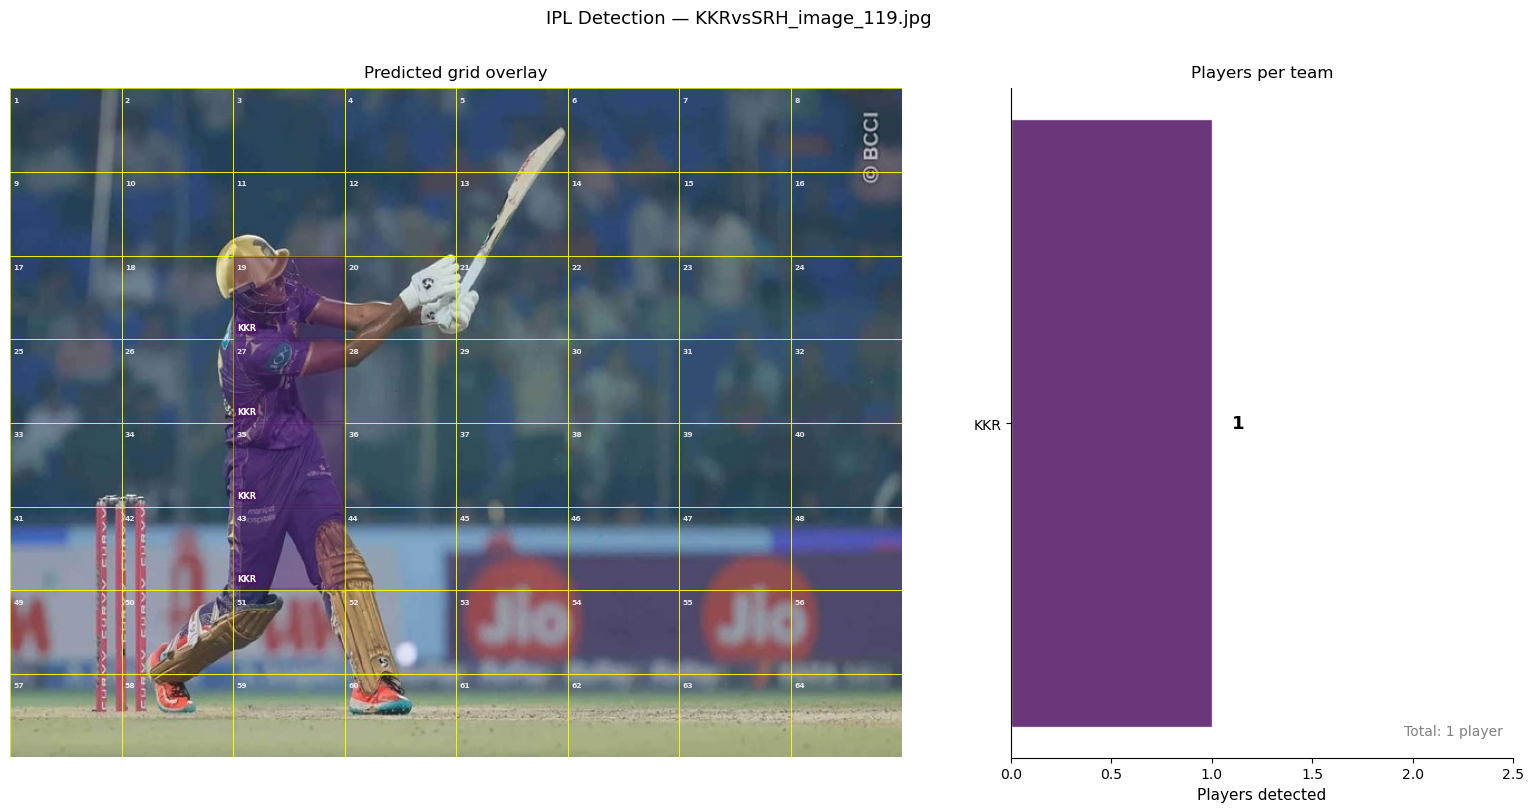

{'c01': 0, 'c02': 0, 'c03': 0, 'c04': 0, 'c05': 0, 'c06': 0, 'c07': 0, 'c08': 0, 'c09': 0, 'c10': 0, 'c11': 0, 'c12': 0, 'c13': 0, 'c14': 0, 'c15': 0, 'c16': 0, 'c17': 0, 'c18': 0, 'c19': 4, 'c20': 0, 'c21': 0, 'c22': 0, 'c23': 0, 'c24': 0, 'c25': 0, 'c26': 0, 'c27': 4, 'c28': 0, 'c29': 0, 'c30': 0, 'c31': 0, 'c32': 0, 'c33': 0, 'c34': 0, 'c35': 4, 'c36': 0, 'c37': 0, 'c38': 0, 'c39': 0, 'c40': 0, 'c41': 0, 'c42': 0, 'c43': 4, 'c44': 0, 'c45': 0, 'c46': 0, 'c47': 0, 'c48': 0, 'c49': 0, 'c50': 0, 'c51': 0, 'c52': 0, 'c53': 0, 'c54': 0, 'c55': 0, 'c56': 0, 'c57': 0, 'c58': 0, 'c59': 0, 'c60': 0, 'c61': 0, 'c62': 0, 'c63': 0, 'c64': 0}
{'CSK': 0, 'DC': 0, 'GT': 0, 'KKR': 1, 'LSG': 0, 'MI': 0, 'PBKS': 0, 'RCB': 0, 'RR': 0, 'SRH': 0}


In [73]:
preds, counts = predict_image_func(img_path, model)
print(preds)
print(counts)